# CSE 482 Project – Part II: Data Analysis

**Project topic:** Movie Recommendation System using Collaborative Filtering  
**Dataset:** MovieLens latest-small  
**Database:** MySQL running in Docker (`cse482_movielens`)

This notebook performs the Part II data analysis work:

1. Define the recommendation problem.
2. Select features used for modeling.
3. Train and evaluate user-based and item-based collaborative filtering models.
4. Compare model performance on a held-out test set.
5. Produce visualizations for the Part II report.

The project directions require both:
- **User-based nearest-neighbor collaborative filtering**
- **Item-based nearest-neighbor collaborative filtering**

Both methods are implemented below using top-*k* nearest neighbors and weighted-average rating prediction.


## 1. Setup

This notebook path:

```text
CSE482_Project/
├── dataset/
├── reports/
├── notebooks/
├── database/
└── docker-compose.yml
```



In [33]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sqlalchemy import create_engine, text


from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import csr_matrix


pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

RANDOM_STATE = 42
TOP_K = 100

print("Libraries loaded.")

Libraries loaded.


## 2. Connect to MySQL and Load Data

For Part II, the model reads from the MySQL database created in Part I.


In [34]:
MYSQL_USER = "cse482_user"
MYSQL_PASSWORD = "cse482_password"
MYSQL_HOST = "localhost"
MYSQL_PORT = 3307
MYSQL_DATABASE = "cse482_movielens"

db_engine = create_engine(
    f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DATABASE}",
    future=True
)

with db_engine.connect() as conn:
    result = conn.execute(text("SELECT 1;"))
    print("Connected:", result.fetchone())

Connected: (1,)


In [35]:
# Load tables from MySQL
ratings = pd.read_sql("SELECT * FROM ratings;", con=db_engine)
movies = pd.read_sql("SELECT * FROM movies;", con=db_engine)
movies_genres = pd.read_sql("SELECT * FROM movies_genres;", con=db_engine)
ratings_with_movies = pd.read_sql("SELECT * FROM ratings_with_movies;", con=db_engine)

print("ratings shape:", ratings.shape)
print("movies shape:", movies.shape)
print("movies_genres shape:", movies_genres.shape)
print("ratings_with_movies shape:", ratings_with_movies.shape)

ratings.head()

ratings shape: (100836, 5)
movies shape: (9742, 3)
movies_genres shape: (9742, 23)
ratings_with_movies shape: (100836, 7)


,userId,movieId,rating,timestamp,rating_datetime
0,1,1,4.0,964982703,2000-07-30 18:45:03
1,1,3,4.0,964981247,2000-07-30 18:20:47
2,1,6,4.0,964982224,2000-07-30 18:37:04
3,1,47,5.0,964983815,2000-07-30 19:03:35
4,1,50,5.0,964982931,2000-07-30 18:48:51


## 3. Problem Definition

The project answers the following questions:

1. Can we predict how a user would rate a movie they have not rated?
2. Which method performs better on the test set: user-based collaborative filtering or item-based collaborative filtering?
3. Can we use movie genre metadata to better understand recommendation patterns?
4. Which movies can be recommended to a selected user based on historical rating behavior?

The target variable is:

```text
rating
```

The primary prediction task is rating prediction on unseen user-movie pairs.


## 4. Feature Selection

The main features used are:

| Feature | Role |
|---|---|
| `userId` | Identifies each user |
| `movieId` | Identifies each movie |
| `rating` | Target value and user preference signal |
| `genres` | Additional movie metadata for interpretation and possible recommendation improvement |
| `rating_datetime` | Used for descriptive analysis, not directly in the model |

For collaborative filtering, the key modeling structure is the **user-item rating matrix**, where rows are users, columns are movies, and values are ratings.


In [36]:
# Basic summaries
num_users = ratings["userId"].nunique()
num_movies_rated = ratings["movieId"].nunique()
num_ratings = len(ratings)

print("Number of users:", num_users)
print("Number of rated movies:", num_movies_rated)
print("Number of ratings:", num_ratings)
print("Rating range:", ratings["rating"].min(), "to", ratings["rating"].max())
print("Mean rating:", round(ratings["rating"].mean(), 3))

Number of users: 610
Number of rated movies: 9724
Number of ratings: 100836
Rating range: 0.5 to 5.0
Mean rating: 3.502


## 5. Initial Visualization and Data Exploration

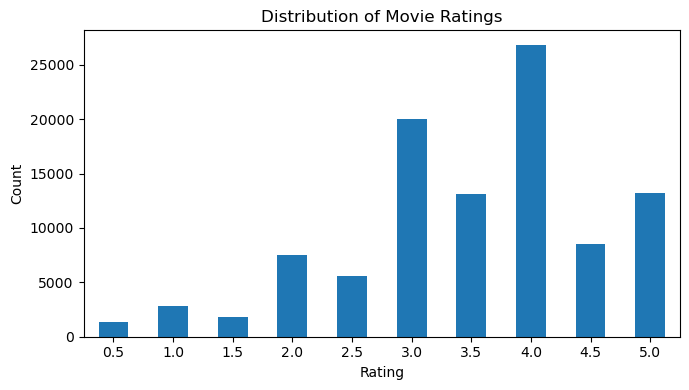

In [37]:
# Rating distribution
plt.figure(figsize=(7, 4))
ratings["rating"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Distribution of Movie Ratings")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

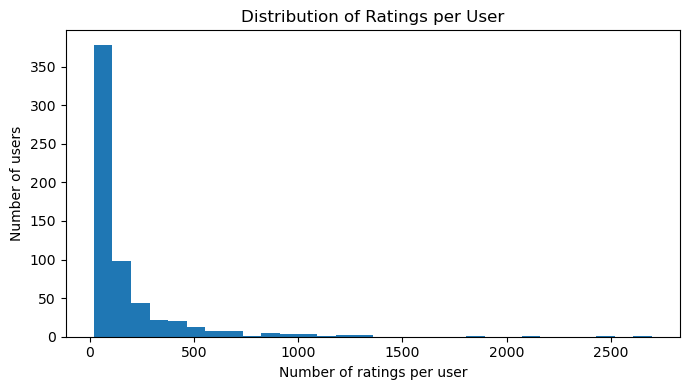

count     610.000000
mean      165.304918
std       269.480584
min        20.000000
25%        35.000000
50%        70.500000
75%       168.000000
max      2698.000000
dtype: float64

In [38]:
# Ratings per user
ratings_per_user = ratings.groupby("userId").size()

plt.figure(figsize=(7, 4))
plt.hist(ratings_per_user, bins=30)
plt.xlabel("Number of ratings per user")
plt.ylabel("Number of users")
plt.title("Distribution of Ratings per User")
plt.tight_layout()
plt.show()

ratings_per_user.describe()

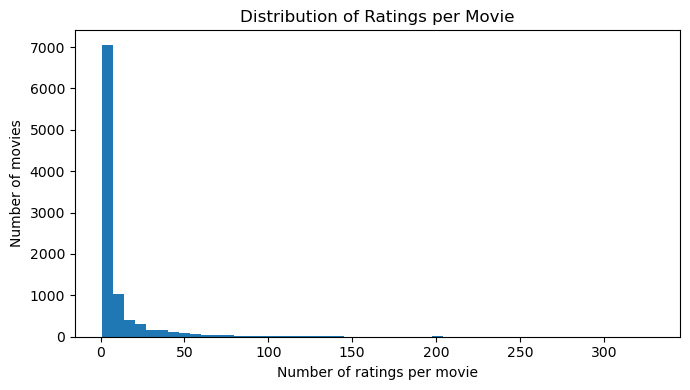

count    9724.000000
mean       10.369807
std        22.401005
min         1.000000
25%         1.000000
50%         3.000000
75%         9.000000
max       329.000000
dtype: float64

In [39]:
# Ratings per movie
ratings_per_movie = ratings.groupby("movieId").size()

plt.figure(figsize=(7, 4))
plt.hist(ratings_per_movie, bins=50)
plt.xlabel("Number of ratings per movie")
plt.ylabel("Number of movies")
plt.title("Distribution of Ratings per Movie")
plt.tight_layout()
plt.show()

ratings_per_movie.describe()

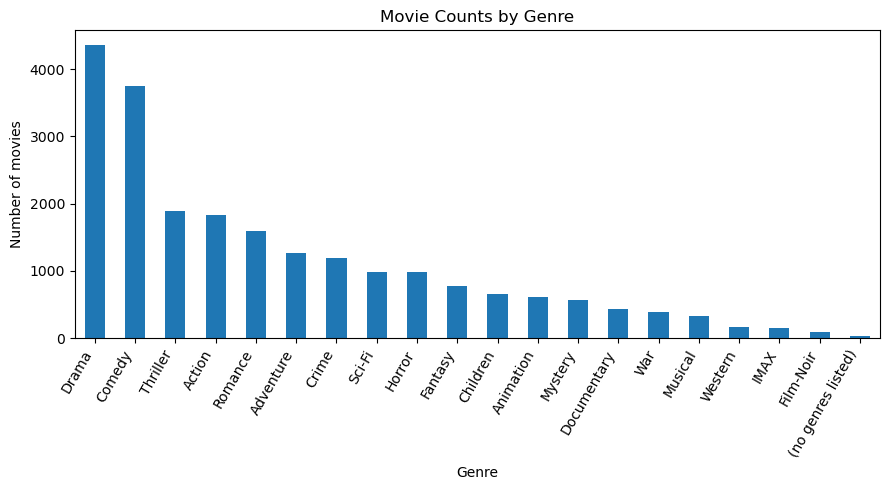

Drama                 4361
Comedy                3756
Thriller              1894
Action                1828
Romance               1596
Adventure             1263
Crime                 1199
Sci-Fi                 980
Horror                 978
Fantasy                779
Children               664
Animation              611
Mystery                573
Documentary            440
War                    382
Musical                334
Western                167
IMAX                   158
Film-Noir               87
(no genres listed)      34
dtype: int64

In [40]:
# Genre distribution
genre_cols = [c for c in movies_genres.columns if c not in ["movieId", "title", "genres"]]
genre_counts = movies_genres[genre_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
genre_counts.plot(kind="bar")
plt.xlabel("Genre")
plt.ylabel("Number of movies")
plt.title("Movie Counts by Genre")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

genre_counts

In [41]:
# Matrix sparsity
possible_pairs = num_users * num_movies_rated
density = num_ratings / possible_pairs
sparsity = 1 - density

print("Possible user-movie pairs:", possible_pairs)
print("Observed ratings:", num_ratings)
print("Matrix density:", round(density, 4))
print("Matrix sparsity:", round(sparsity, 4))

Possible user-movie pairs: 5931640
Observed ratings: 100836
Matrix density: 0.017
Matrix sparsity: 0.983


## 6. Create Training and Test Sets

The project directions require a train/test split and comparison of model performance.

A stratified split by `userId` is used so that each user's ratings are represented in both training and test data.


In [42]:
train_ratings, test_ratings = train_test_split(
    ratings,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=ratings["userId"]
)

print("Training set shape:", train_ratings.shape)
print("Test set shape:", test_ratings.shape)

print("Unique users in training:", train_ratings["userId"].nunique())
print("Unique users in test:", test_ratings["userId"].nunique())

Training set shape: (80668, 5)
Test set shape: (20168, 5)
Unique users in training: 610
Unique users in test: 610


## 7. Build User-Item Matrix from Training Data

Only training data is used to compute similarities. This avoids leaking test information into the model.


In [43]:
train_matrix = train_ratings.pivot_table(
    index="userId",
    columns="movieId",
    values="rating"
)

print("Training user-item matrix shape:", train_matrix.shape)
train_matrix.head()

Training user-item matrix shape: (610, 8977)


movieId,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,...,187595,187717,188189,188301,188675,188797,189111,189333,189381,189547,189713,190183,190209,190213,190215,190219,190221,193565,193567,193571,193579,193581,193583,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [44]:

global_mean = train_ratings["rating"].mean()
user_means = train_ratings.groupby("userId")["rating"].mean().to_dict()
movie_means = train_ratings.groupby("movieId")["rating"].mean().to_dict()


user_rating_dict = train_ratings.groupby("userId").apply(
    lambda df: dict(zip(df["movieId"], df["rating"]))
).to_dict()


movie_rating_dict = train_ratings.groupby("movieId").apply(
    lambda df: dict(zip(df["userId"], df["rating"]))
).to_dict()

print("Global mean rating:", round(global_mean, 3))

/var/folders/3v/625m8sq96616cydwkmzrypb80000gn/T/ipykernel_52390/3621624547.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  user_rating_dict = train_ratings.groupby("userId").apply(
/var/folders/3v/625m8sq96616cydwkmzrypb80000gn/T/ipykernel_52390/3621624547.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  movie_rating_dict = train_ratings.groupby("movieId").apply(


Global mean rating: 3.501


## 8. Baseline Model

A simple baseline is useful for comparison. This model predicts a user's average rating if available, otherwise the global mean rating.


In [45]:
def baseline_predict(user_id, movie_id):
    return user_means.get(user_id, global_mean)

baseline_predictions = [
    baseline_predict(row.userId, row.movieId)
    for row in test_ratings.itertuples(index=False)
]

baseline_rmse = np.sqrt(mean_squared_error(test_ratings["rating"], baseline_predictions))
baseline_mae = mean_absolute_error(test_ratings["rating"], baseline_predictions)

print("Baseline RMSE:", round(baseline_rmse, 4))
print("Baseline MAE:", round(baseline_mae, 4))

Baseline RMSE: 0.9413
Baseline MAE: 0.7347


## 9. User-Based Collaborative Filtering

For each user, the model finds the top-*k* nearest users based on rating behavior.  
The predicted rating is a weighted average of ratings from similar users who rated the target movie.


In [46]:
# User-user similarity using cosine similarity
# Missing ratings are filled with 0 for similarity calculation.
user_matrix_filled = train_matrix.fillna(0)

user_similarity_matrix = cosine_similarity(user_matrix_filled)
user_ids = train_matrix.index.to_numpy()

user_similarity_df = pd.DataFrame(
    user_similarity_matrix,
    index=user_ids,
    columns=user_ids
)

print("User similarity matrix shape:", user_similarity_df.shape)
user_similarity_df.iloc[:5, :5]

User similarity matrix shape: (610, 610)


,1,2,3,4,5
1,1.000000,0.033978,0.052314,0.164108,0.055953
2,0.033978,1.000000,0.000000,0.000000,0.020710
3,0.052314,0.000000,1.000000,0.000000,0.005856
4,0.164108,0.000000,0.000000,1.000000,0.107156
5,0.055953,0.020710,0.005856,0.107156,1.000000


In [47]:
# Precompute top-k nearest users for every user
top_user_neighbors = {}

for user_id in user_ids:
    sims = user_similarity_df.loc[user_id].drop(index=user_id)
    top_neighbors = sims.sort_values(ascending=False).head(TOP_K)
    top_user_neighbors[user_id] = list(zip(top_neighbors.index, top_neighbors.values))

print("Example top user neighbors for user", user_ids[0])
top_user_neighbors[user_ids[0]][:10]

Example top user neighbors for user 1


[(368, 0.2904547653697922),
 (91, 0.2866052065621174),
 (64, 0.28473218991341104),
 (330, 0.2797915944301787),
 (202, 0.2792711952498115),
 (561, 0.2781236610858644),
 (57, 0.27539511480162276),
 (135, 0.2744304094098194),
 (288, 0.2730317198391669),
 (266, 0.27264357400297456)]

In [48]:
def predict_user_based(user_id, movie_id, k=TOP_K):
    """Predict rating using top-k similar users who rated the target movie."""

    if user_id not in top_user_neighbors:
        return movie_means.get(movie_id, global_mean)

    weighted_sum = 0.0
    similarity_sum = 0.0

    for neighbor_id, sim in top_user_neighbors[user_id][:k]:
        neighbor_ratings = user_rating_dict.get(neighbor_id, {})

        if movie_id in neighbor_ratings and sim > 0:
            weighted_sum += sim * neighbor_ratings[movie_id]
            similarity_sum += abs(sim)

    if similarity_sum > 0:
        pred = weighted_sum / similarity_sum
    else:
        pred = user_means.get(user_id, movie_means.get(movie_id, global_mean))

    return float(np.clip(pred, 0.5, 5.0))

In [49]:
# Evaluate user-based CF
user_based_predictions = [
    predict_user_based(row.userId, row.movieId)
    for row in test_ratings.itertuples(index=False)
]

user_based_rmse = np.sqrt(mean_squared_error(test_ratings["rating"], user_based_predictions))
user_based_mae = mean_absolute_error(test_ratings["rating"], user_based_predictions)

print("User-based CF RMSE:", round(user_based_rmse, 4))
print("User-based CF MAE:", round(user_based_mae, 4))

User-based CF RMSE: 0.9676
User-based CF MAE: 0.7476


## 10. Item-Based Collaborative Filtering

For each item, the model finds the top-*k* nearest items based on how users rated them.  
The predicted rating is a weighted average of the user's ratings on similar items.


In [50]:
# Build item-user matrix from training data
item_user_matrix = train_matrix.T.fillna(0)
item_ids = item_user_matrix.index.to_numpy()

# Sparse matrix improves memory efficiency
item_user_sparse = csr_matrix(item_user_matrix.values)

print("Item-user matrix shape:", item_user_matrix.shape)

Item-user matrix shape: (8977, 610)


In [51]:
# Nearest-neighbor model for item similarity
# n_neighbors includes the item itself, so we request TOP_K + 1 and remove itself.
n_neighbors = min(TOP_K + 1, len(item_ids))

item_nn_model = NearestNeighbors(
    n_neighbors=n_neighbors,
    metric="cosine",
    algorithm="brute"
)

item_nn_model.fit(item_user_sparse)

distances, indices = item_nn_model.kneighbors(item_user_sparse)

top_item_neighbors = {}

for item_position, movie_id in enumerate(item_ids):
    neighbor_list = []
    for dist, idx in zip(distances[item_position], indices[item_position]):
        neighbor_movie_id = item_ids[idx]
        if neighbor_movie_id == movie_id:
            continue
        sim = 1 - dist
        if sim > 0:
            neighbor_list.append((neighbor_movie_id, sim))
    top_item_neighbors[movie_id] = neighbor_list[:TOP_K]

print("Example top item neighbors for movie", item_ids[0])
top_item_neighbors[item_ids[0]][:10]

Example top item neighbors for movie 1


[(4306, 0.4716984439609031),
 (480, 0.4714791289579865),
 (260, 0.4591576711979777),
 (780, 0.45851943127575767),
 (3114, 0.45378465394395007),
 (4886, 0.45265898168112395),
 (356, 0.4522184514483698),
 (588, 0.4476924747222909),
 (1210, 0.44552996452782134),
 (1196, 0.4437873528779026)]

In [52]:
def predict_item_based(user_id, movie_id, k=TOP_K):
    """Predict rating using the user's ratings of top-k similar items."""

    user_ratings = user_rating_dict.get(user_id, {})

    if movie_id not in top_item_neighbors:
        return user_means.get(user_id, movie_means.get(movie_id, global_mean))

    weighted_sum = 0.0
    similarity_sum = 0.0

    for neighbor_movie_id, sim in top_item_neighbors[movie_id][:k]:
        if neighbor_movie_id in user_ratings and sim > 0:
            weighted_sum += sim * user_ratings[neighbor_movie_id]
            similarity_sum += abs(sim)

    if similarity_sum > 0:
        pred = weighted_sum / similarity_sum
    else:
        pred = user_means.get(user_id, movie_means.get(movie_id, global_mean))

    return float(np.clip(pred, 0.5, 5.0))

In [53]:
# Evaluate item-based CF
item_based_predictions = [
    predict_item_based(row.userId, row.movieId)
    for row in test_ratings.itertuples(index=False)
]

item_based_rmse = np.sqrt(mean_squared_error(test_ratings["rating"], item_based_predictions))
item_based_mae = mean_absolute_error(test_ratings["rating"], item_based_predictions)

print("Item-based CF RMSE:", round(item_based_rmse, 4))
print("Item-based CF MAE:", round(item_based_mae, 4))

Item-based CF RMSE: 0.9016
Item-based CF MAE: 0.6801


## 11. Compare Model Performance

Lower RMSE and MAE indicate better prediction performance.


In [54]:
results = pd.DataFrame({
    "Model": ["Baseline User Mean", "User-Based CF", "Item-Based CF"],
    "RMSE": [baseline_rmse, user_based_rmse, item_based_rmse],
    "MAE": [baseline_mae, user_based_mae, item_based_mae]
})

results["RMSE"] = results["RMSE"].round(4)
results["MAE"] = results["MAE"].round(4)

results

,Model,RMSE,MAE
0,Baseline User Mean,0.9413,0.7347
1,User-Based CF,0.9676,0.7476
2,Item-Based CF,0.9016,0.6801


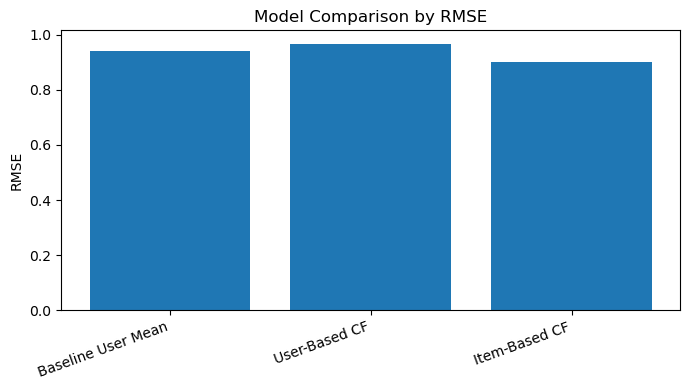

In [55]:
plt.figure(figsize=(7, 4))
plt.bar(results["Model"], results["RMSE"])
plt.ylabel("RMSE")
plt.title("Model Comparison by RMSE")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

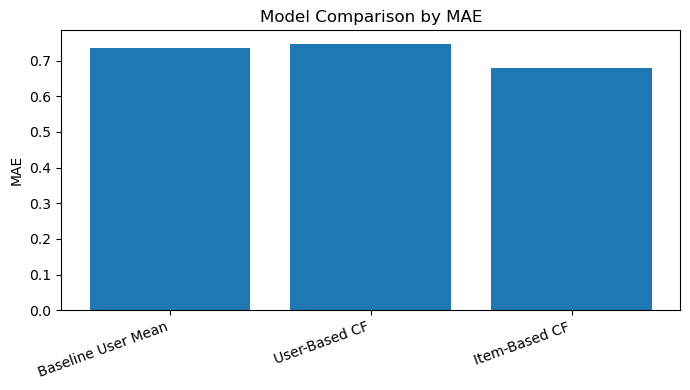

In [56]:
plt.figure(figsize=(7, 4))
plt.bar(results["Model"], results["MAE"])
plt.ylabel("MAE")
plt.title("Model Comparison by MAE")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 12. Prediction vs Actual Visualization

In [57]:
prediction_comparison = test_ratings[["userId", "movieId", "rating"]].copy()
prediction_comparison["baseline_pred"] = baseline_predictions
prediction_comparison["user_based_pred"] = user_based_predictions
prediction_comparison["item_based_pred"] = item_based_predictions

prediction_comparison = prediction_comparison.merge(movies, on="movieId", how="left")
prediction_comparison.head()

,userId,movieId,rating,baseline_pred,user_based_pred,item_based_pred,title,genres
0,318,2571,3.5,3.751778,4.227407,3.742382,"Matrix, The (1999)",Action|Sci-Fi|Thriller
1,288,3147,3.0,3.160545,4.083050,3.843338,"Green Mile, The (1999)",Crime|Drama
2,314,23,3.0,3.049020,3.723802,1.946382,Assassins (1995),Action|Crime|Thriller
3,184,191005,4.5,3.775701,3.775701,3.775701,Gintama (2017),Action|Adventure|Comedy|Sci-Fi
4,414,5415,2.0,3.398981,3.730233,2.856682,Divine Secrets of the Ya-Ya Sisterhood (2002),Comedy|Drama


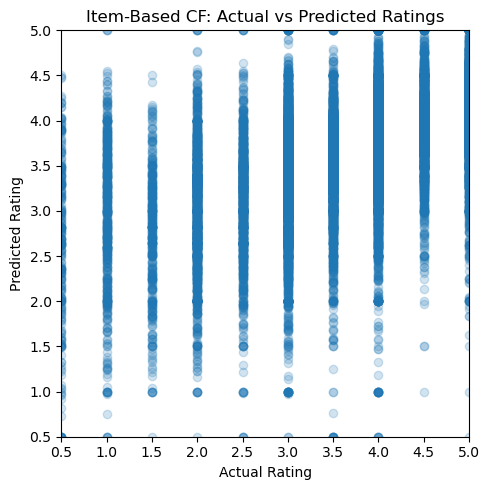

In [58]:
# Scatter plot: actual vs predicted for item-based CF
plt.figure(figsize=(5, 5))
plt.scatter(
    prediction_comparison["rating"],
    prediction_comparison["item_based_pred"],
    alpha=0.2
)
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Item-Based CF: Actual vs Predicted Ratings")
plt.xlim(0.5, 5.0)
plt.ylim(0.5, 5.0)
plt.tight_layout()
plt.show()

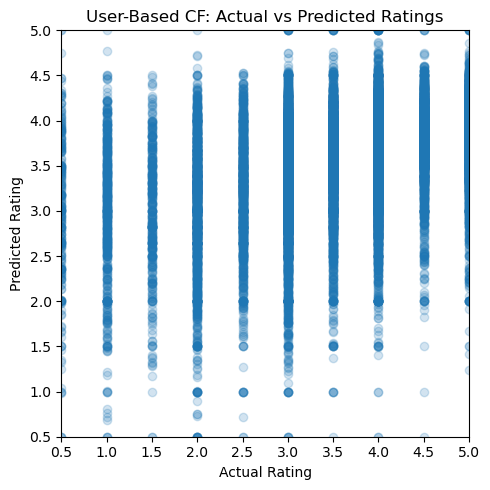

In [59]:
# Scatter plot: actual vs predicted for user-based CF
plt.figure(figsize=(5, 5))
plt.scatter(
    prediction_comparison["rating"],
    prediction_comparison["user_based_pred"],
    alpha=0.2
)
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("User-Based CF: Actual vs Predicted Ratings")
plt.xlim(0.5, 5.0)
plt.ylim(0.5, 5.0)
plt.tight_layout()
plt.show()

## 13. Recommendation Examples for a Selected User

This section supports the later web interface requirement.  
The same logic can be used in the web app to:

- display movies a user already rated
- recommend movies the user has not rated
- show similar users


In [60]:
selected_user = 1

rated_by_selected_user = ratings_with_movies[ratings_with_movies["userId"] == selected_user][
    ["movieId", "title", "genres", "rating"]
].sort_values("rating", ascending=False)

print("Number of movies rated by selected user:", len(rated_by_selected_user))
rated_by_selected_user.head(10)

Number of movies rated by selected user: 232


,movieId,title,genres,rating
231,5060,M*A*S*H (a.k.a. MASH) (1970),Comedy|Drama|War,5.0
185,2872,Excalibur (1981),Adventure|Fantasy,5.0
89,1291,Indiana Jones and the Last Crusade (1989),Action|Adventure,5.0
90,1298,Pink Floyd: The Wall (1982),Drama|Musical,5.0
190,2948,From Russia with Love (1963),Action|Adventure|Thriller,5.0
189,2947,Goldfinger (1964),Action|Adventure|Thriller,5.0
188,2944,"Dirty Dozen, The (1967)",Action|Drama|War,5.0
186,2899,Gulliver's Travels (1939),Adventure|Animation|Children,5.0
184,2858,American Beauty (1999),Drama|Romance,5.0
179,2700,"South Park: Bigger, Longer and Uncut (1999)",Animation|Comedy|Musical,5.0


In [61]:
def get_similar_users(user_id, n=10):
    if user_id not in top_user_neighbors:
        return pd.DataFrame(columns=["similar_userId", "similarity"])

    neighbors = top_user_neighbors[user_id][:n]
    return pd.DataFrame(neighbors, columns=["similar_userId", "similarity"])

similar_users_example = get_similar_users(selected_user, n=10)
similar_users_example

,similar_userId,similarity
0,368,0.290455
1,91,0.286605
2,64,0.284732
3,330,0.279792
4,202,0.279271
5,561,0.278124
6,57,0.275395
7,135,0.274430
8,288,0.273032
9,266,0.272644


In [62]:
def recommend_movies_item_based(user_id, n=10, min_num_ratings=20):
    """Recommend movies not rated by the user using item-based CF predictions."""

    rated_movies = set(user_rating_dict.get(user_id, {}).keys())

    movie_popularity = train_ratings.groupby("movieId").size()
    candidate_movies = [
        movie_id for movie_id in item_ids
        if movie_id not in rated_movies and movie_popularity.get(movie_id, 0) >= min_num_ratings
    ]

    scored = []
    for movie_id in candidate_movies:
        score = predict_item_based(user_id, movie_id)
        scored.append((movie_id, score))

    recs = pd.DataFrame(scored, columns=["movieId", "predicted_rating"])
    recs = recs.merge(movies, on="movieId", how="left")
    recs = recs.sort_values("predicted_rating", ascending=False).head(n)

    return recs[["movieId", "title", "genres", "predicted_rating"]]

item_recommendations_example = recommend_movies_item_based(selected_user, n=10)
item_recommendations_example

,movieId,title,genres,predicted_rating
393,2384,Babe: Pig in the City (1998),Adventure|Children|Drama,5.0
766,49272,Casino Royale (2006),Action|Adventure|Thriller,5.0
73,307,Three Colors: Blue (Trois couleurs: Bleu) (1993),Drama,5.0
860,91529,"Dark Knight Rises, The (2012)",Action|Adventure|Crime|IMAX,5.0
143,671,Mystery Science Theater 3000: The Movie (1996),Comedy|Sci-Fi,5.0
705,8970,Finding Neverland (2004),Drama,5.0
459,3087,Scrooged (1988),Comedy|Fantasy|Romance,5.0
862,91658,"Girl with the Dragon Tattoo, The (2011)",Drama|Thriller,5.0
706,8972,National Treasure (2004),Action|Adventure|Drama|Mystery|Thriller,5.0
863,92259,Intouchables (2011),Comedy|Drama,5.0


In [63]:
def recommend_movies_user_based(user_id, n=10, min_num_ratings=20):
    """Recommend movies not rated by the user using user-based CF predictions."""

    rated_movies = set(user_rating_dict.get(user_id, {}).keys())

    movie_popularity = train_ratings.groupby("movieId").size()
    candidate_movies = [
        movie_id for movie_id in train_ratings["movieId"].unique()
        if movie_id not in rated_movies and movie_popularity.get(movie_id, 0) >= min_num_ratings
    ]

    scored = []
    for movie_id in candidate_movies:
        score = predict_user_based(user_id, movie_id)
        scored.append((movie_id, score))

    recs = pd.DataFrame(scored, columns=["movieId", "predicted_rating"])
    recs = recs.merge(movies, on="movieId", how="left")
    recs = recs.sort_values("predicted_rating", ascending=False).head(n)

    return recs[["movieId", "title", "genres", "predicted_rating"]]

user_recommendations_example = recommend_movies_user_based(selected_user, n=10)
user_recommendations_example

,movieId,title,genres,predicted_rating
296,318,"Shawshank Redemption, The (1994)",Crime|Drama,4.566034
866,475,In the Name of the Father (1993),Drama,4.539098
30,4973,"Amelie (Fabuleux destin d'Amélie Poulain, Le) ...",Comedy|Romance,4.520750
126,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,4.513507
45,858,"Godfather, The (1972)",Crime|Drama,4.513029
139,79132,Inception (2010),Action|Crime|Drama|Mystery|Sci-Fi|Thriller|IMAX,4.510678
123,92259,Intouchables (2011),Comedy|Drama,4.500000
50,1244,Manhattan (1979),Comedy|Drama|Romance,4.495933
766,1223,"Grand Day Out with Wallace and Gromit, A (1989)",Adventure|Animation|Children|Comedy|Sci-Fi,4.485804
733,106696,Frozen (2013),Adventure|Animation|Comedy|Fantasy|Musical|Rom...,4.484587


## 14. Save Part II Outputs

These output files can be referenced later in the report and web app.


In [64]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
REPORTS_DIR = PROJECT_ROOT / "reports"
REPORTS_DIR.mkdir(exist_ok=True)

results.to_csv(REPORTS_DIR / "part2_model_comparison.csv", index=False)
prediction_comparison.to_csv(REPORTS_DIR / "part2_prediction_comparison.csv", index=False)
item_recommendations_example.to_csv(REPORTS_DIR / "part2_item_based_recommendations_user1.csv", index=False)
user_recommendations_example.to_csv(REPORTS_DIR / "part2_user_based_recommendations_user1.csv", index=False)
similar_users_example.to_csv(REPORTS_DIR / "part2_similar_users_user1.csv", index=False)

print("Saved Part II outputs to:", REPORTS_DIR)

Saved Part II outputs to: /Users/mehrshad/Documents/CSE482_Project/reports


## 15. Part II Summary

This notebook completed the data analysis stage of the project.

Summary of completed tasks:

1. Loaded preprocessed MovieLens data from MySQL.
2. Selected user IDs, movie IDs, ratings, and genre metadata as key features.
3. Created training and test sets.
4. Implemented a baseline model.
5. Implemented user-based collaborative filtering using top-*k* similar users.
6. Implemented item-based collaborative filtering using top-*k* similar movies.
7. Evaluated models using RMSE and MAE.
8. Generated initial visualizations and recommendation examples.

The model comparison table above should be used in the Part II Word report.
